## **BLINKIT ANALYSIS IN PYTHON**


### **Import libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #for advance analysis

### **Import Raw Data**

In [5]:
df = pd.read_csv("D:/blinkit project/BlinkIT Grocery Data.csv")

### **Sample Data**

In [7]:
df.head(10) # top 10 rows

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2014,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [8]:
df.tail(10) #bottom 10 data

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8513,Regular,DRY23,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,NaN,42.9112,4.0
8514,low fat,FDA11,Baking Goods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,NaN,94.7436,4.0
8515,low fat,FDK38,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,NaN,149.1734,4.0
8516,low fat,FDO38,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,NaN,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,NaN,222.3772,4.0
8518,low fat,NCT53,Health and Hygiene,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


### **Size Of Data**

In [10]:
print("size of data", df.shape)

size of data (8523, 12)


### **Field Info**

In [12]:
df.columns #the total info of colmns present in our data

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

### **Data Types**

In [14]:
df.dtypes #the datatypes of each and every column present in our database

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

### **Data Cleaning**

In [16]:
print(df['Item Fat Content'].unique()) #unique values present for the column  Item Fat Content 

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [17]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF': 'Low Fat',
                                                         'low fat':'Low Fat',
                                                         'reg':'Regular'})

### **BUSINESS REQUIREMENTS**

#### **KPI's REQUIREMENTS**

##### **Total Sales**

In [21]:
total_sales = df['Sales'].sum()
print(f"Total Sales: ${total_sales:,.1f}") #, for thousand separator and .1f to show 1 digit after decimal point and : for to show the value in one particular formuls

Total Sales: $1,201,681.5


##### **Avg Sales**

In [29]:
avg_sales = df['Sales'].mean()
print(f"avg Sales: ${avg_sales:,.1f}")

avg Sales: $141.0


##### **No Of Items Sold**

In [31]:
no_of_items_sold = df['Sales'].count()
print(f"no_of_items_sold: {no_of_items_sold:,.1f}")

no_of_items_sold: 8,523.0


##### **Avg Ratings**

In [ ]:
avg_rating = df['Rating'].mean()
print(f"avg_rating: {avg_rating:,.1f}")

#### **CHARTS REQUIREMENTS**

##### **Total Sales By Fat Content(Donut Chart)**

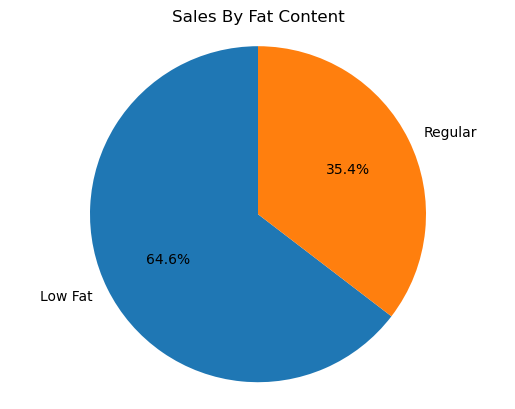

In [35]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
#print(sales_by_fat)
plt.pie(sales_by_fat, 
        labels= sales_by_fat.index,
        autopct = '%.1f%%',
        startangle = 90)
plt.title("Sales By Fat Content")
plt.axis('equal')
plt.show()

##### **Total Sales By Item Type(Bar Chart)**

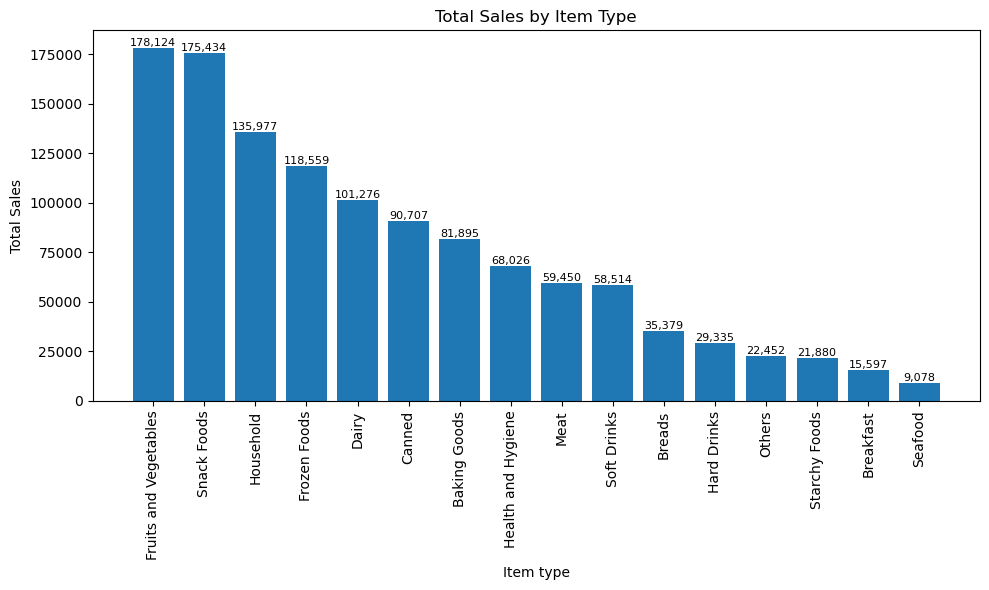

In [69]:
sales_by_item_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending = False)

plt.figure(figsize = (10, 6))
bars = plt.bar(sales_by_item_type.index, sales_by_item_type.values)

plt.xticks(rotation = 90)
plt.xlabel('Item type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{bar.get_height():,.0f}', ha = 'center', va = 'bottom', fontsize = 8)

plt.tight_layout()
plt.show()

##### **Fat Content by Outlets for total sales(Stacked Column Chart)**

In [ ]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack() #Moves Item Fat Content from rows to columns
grouped = grouped[['Regular', 'Low Fat']] #Regular bar appears first Low Fat appears next

ax = grouped.plot(kind = 'bar', figsize = (8, 5), title = 'Outlet tier by Item fat content')  #bars will aligned vertically, to horizontally aligned barh 
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.legend(title = 'Item Fat Content')
for bar in ax.patches: #Contains all bar rectangles drawn on the char
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x position(center)
        bar.get_height(),                    #y position (top of the bar)
        f'{bar.get_height():,.0f}',           #text
        ha='center',
        va='bottom'
    )
plt.tight_layout()
plt.show()

##### **Total Sales By Item Establishment Year(Line Chart)**

In [ ]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize= (9, 5))
plt.plot(sales_by_year.index, sales_by_year.values, marker= 'o', linestyle = '-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Total Sales By Outlet Establishment')

for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize = 8)
plt.tight_layout() 
plt.show()

##### **Total Sales By Outlet Size**

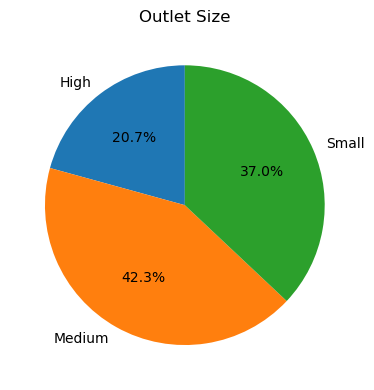

In [39]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4, 4))
plt.pie(sales_by_size, 
        labels=sales_by_size.index,
        autopct = '%.1f%%', 
        startangle = 90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

##### **Total Sales By outlet Location(Funnel Map)**

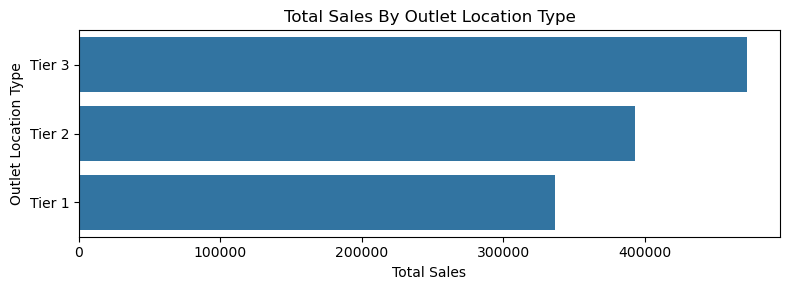

In [67]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index().sort_values('Sales',ascending= False)
plt.figure(figsize=(8, 3))
ax = sns.barplot(x = 'Sales', y = 'Outlet Location Type', data = sales_by_location)

plt.title('Total Sales By Outlet Location Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout()
plt.show()